# Electricity Theft Detection in Distribution Networks using Machine Learning
### B.Tech EEE Capstone Project

**Objective:** Build an ML classifier that flags consumers likely to be
committing electricity theft / meter tampering, using engineered features
derived from smart-meter (AMI) daily consumption data, so utilities can
prioritise field inspections instead of random checks.

**Workflow:** Data Collection → Preprocessing → EDA → Feature Engineering →
Model Training → Evaluation → Deployment (Streamlit demo)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score, ConfusionMatrixDisplay
)
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load Raw Data
Raw dataset: 3000 consumers x 180 days of daily kWh readings, simulated to
mirror real AMI smart-meter data (seasonal + weekly patterns + noise), with
~14% of consumers exhibiting one of five realistic theft/tampering signatures:
`sudden_drop`, `zero_stretches`, `flattened_cap`, `gradual_underreport`,
`periodic_bypass`.

In [6]:
raw = pd.read_csv("../data/smart_meter_data.csv")
print("Raw shape:", raw.shape)
raw[["consumer_id", "theft_type", "label"]].head()

Raw shape: (3000, 183)


,consumer_id,theft_type,label
0,CUST00001,periodic_bypass,1
1,CUST00002,sudden_drop,1
2,CUST00003,none,0
3,CUST00004,none,0
4,CUST00005,none,0


## 2. Data Preprocessing
Real smart-meter feeds have communication gaps -> small % missing values
were injected. We interpolate along each consumer's time series (linear),
falling back to the consumer's own median for any remaining gaps.

In [7]:
date_cols = [c for c in raw.columns if c not in ("consumer_id", "theft_type", "label")]
print("Missing values before cleaning:", raw[date_cols].isna().sum().sum())

daily = raw[date_cols].astype(float)
daily = daily.interpolate(axis=1, limit_direction="both")
daily = daily.fillna(daily.median(axis=1), axis=0)
print("Missing values after cleaning:", daily.isna().sum().sum())

Missing values before cleaning: 5459
Missing values after cleaning: 0


## 3. Exploratory Data Analysis (EDA)

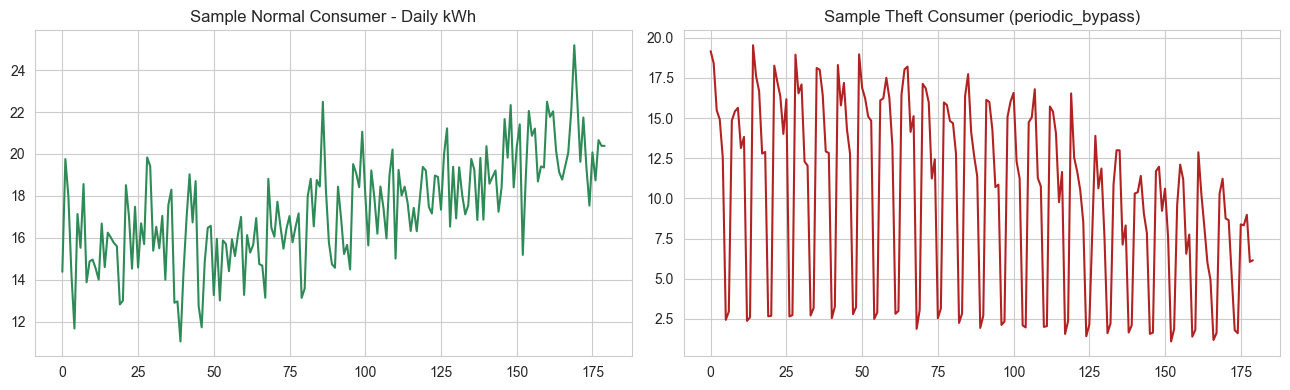

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sample_normal = daily[raw["label"] == 0].iloc[0]
sample_theft = daily[raw["label"] == 1].iloc[0]
axes[0].plot(sample_normal.values, color="seagreen")
axes[0].set_title("Sample Normal Consumer - Daily kWh")
axes[1].plot(sample_theft.values, color="firebrick")
axes[1].set_title(f"Sample Theft Consumer ({raw[raw['label']==1]['theft_type'].iloc[0]})")
plt.tight_layout()
plt.savefig("../report_assets/sample_series.png", dpi=150)
plt.show()

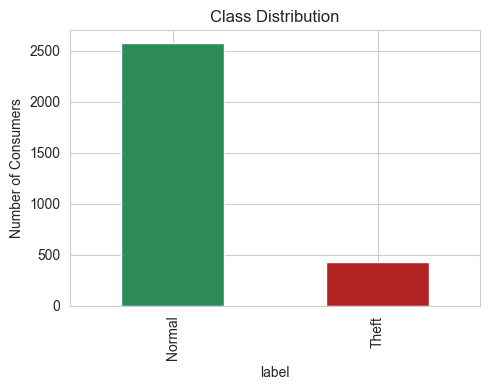

In [9]:
plt.figure(figsize=(5, 4))
raw["label"].map({0: "Normal", 1: "Theft"}).value_counts().plot(
    kind="bar", color=["seagreen", "firebrick"]
)
plt.title("Class Distribution")
plt.ylabel("Number of Consumers")
plt.tight_layout()
plt.savefig("../report_assets/class_distribution.png", dpi=150)
plt.show()

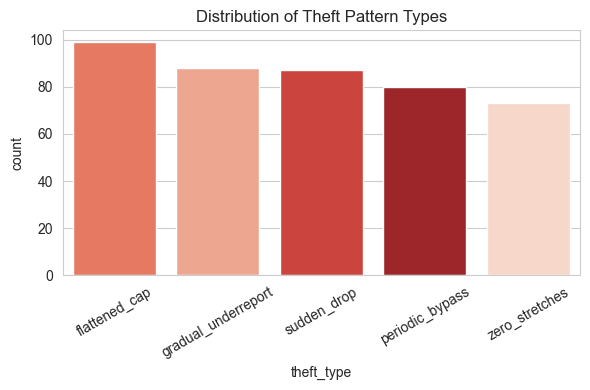

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=raw[raw.label == 1], x="theft_type",
              order=raw[raw.label == 1]["theft_type"].value_counts().index,
              hue="theft_type", palette="Reds_r", legend=False)
plt.xticks(rotation=30)
plt.title("Distribution of Theft Pattern Types")
plt.tight_layout()
plt.savefig("../report_assets/theft_type_distribution.png", dpi=150)
plt.show()

## 4. Feature Engineering
Raw 180-day series are high-dimensional and don't generalise well as direct
model input. We engineer statistical / behavioural features per consumer
that are known (from DGA-analogous domain reasoning for load profiles) to
separate normal usage from tampering signatures:

- `mean_daily_kwh`, `std_daily_kwh`, `coefficient_of_variation`
- `zero_day_fraction` — catches bypass/zero-stretch tampering
- `trend_ratio` (2nd half mean / 1st half mean) — catches gradual under-reporting
- `weekday_weekend_ratio` — catches periodic/weekend-only bypass
- `sudden_drop_count` — catches abrupt meter tampering events
- `weekly_cv`, `near_cap_fraction` — catches flattened/capped readings

In [11]:
import sys
sys.path.append("../data")
from feature_engineering import build_features

feat_df = build_features(raw)
feat_df.to_csv("../data/theft_features_dataset.csv", index=False)
feat_df.head()

,consumer_id,mean_daily_kwh,std_daily_kwh,coefficient_of_variation,min_daily_kwh,max_daily_kwh,median_daily_kwh,zero_day_fraction,trend_ratio,weekday_weekend_ratio,sudden_drop_count,weekly_cv,near_cap_fraction,max_to_mean_ratio,theft_type,Label
0,CUST00001,10.197,5.749,0.5637,1.101,19.529,11.321,0.0000,0.7005,0.1721,25,0.1949,0.0278,1.9151,periodic_bypass,Theft
1,CUST00002,15.519,8.900,0.5735,5.538,30.035,8.435,0.0000,0.2890,0.8765,1,0.5512,0.2722,1.9354,sudden_drop,Theft
2,CUST00003,17.386,2.520,0.1449,11.052,25.188,17.291,0.0000,1.1882,0.9747,0,0.1043,0.2556,1.4488,none,Normal
3,CUST00004,21.693,2.566,0.1183,16.038,28.356,21.664,0.0000,1.0838,0.9480,0,0.0538,0.2889,1.3071,none,Normal
4,CUST00005,8.321,3.551,0.4268,0.000,16.397,8.476,0.0056,0.5300,1.2267,4,0.3446,0.1000,1.9705,none,Normal


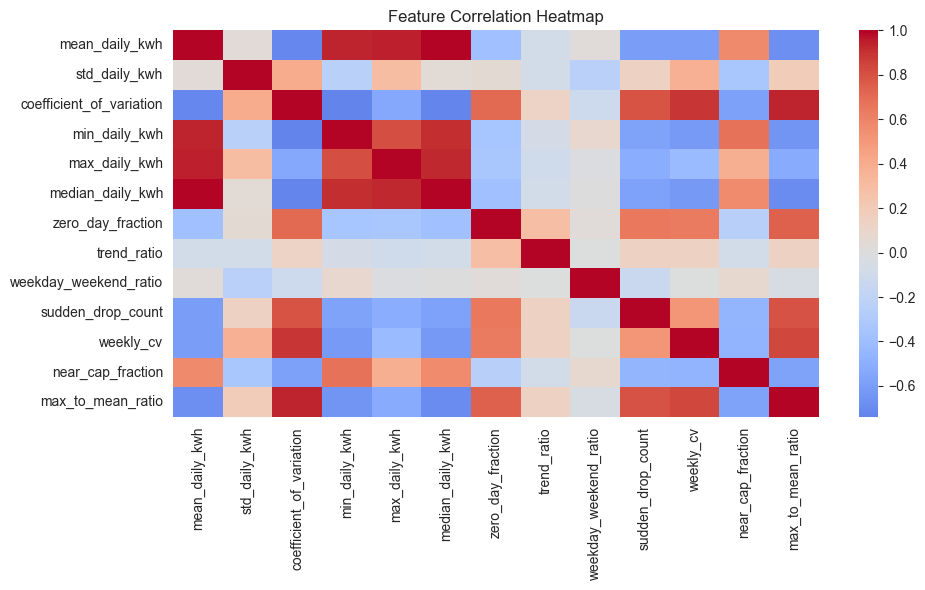

In [12]:
plt.figure(figsize=(10, 6))
corr = feat_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../report_assets/correlation_heatmap.png", dpi=150)
plt.show()

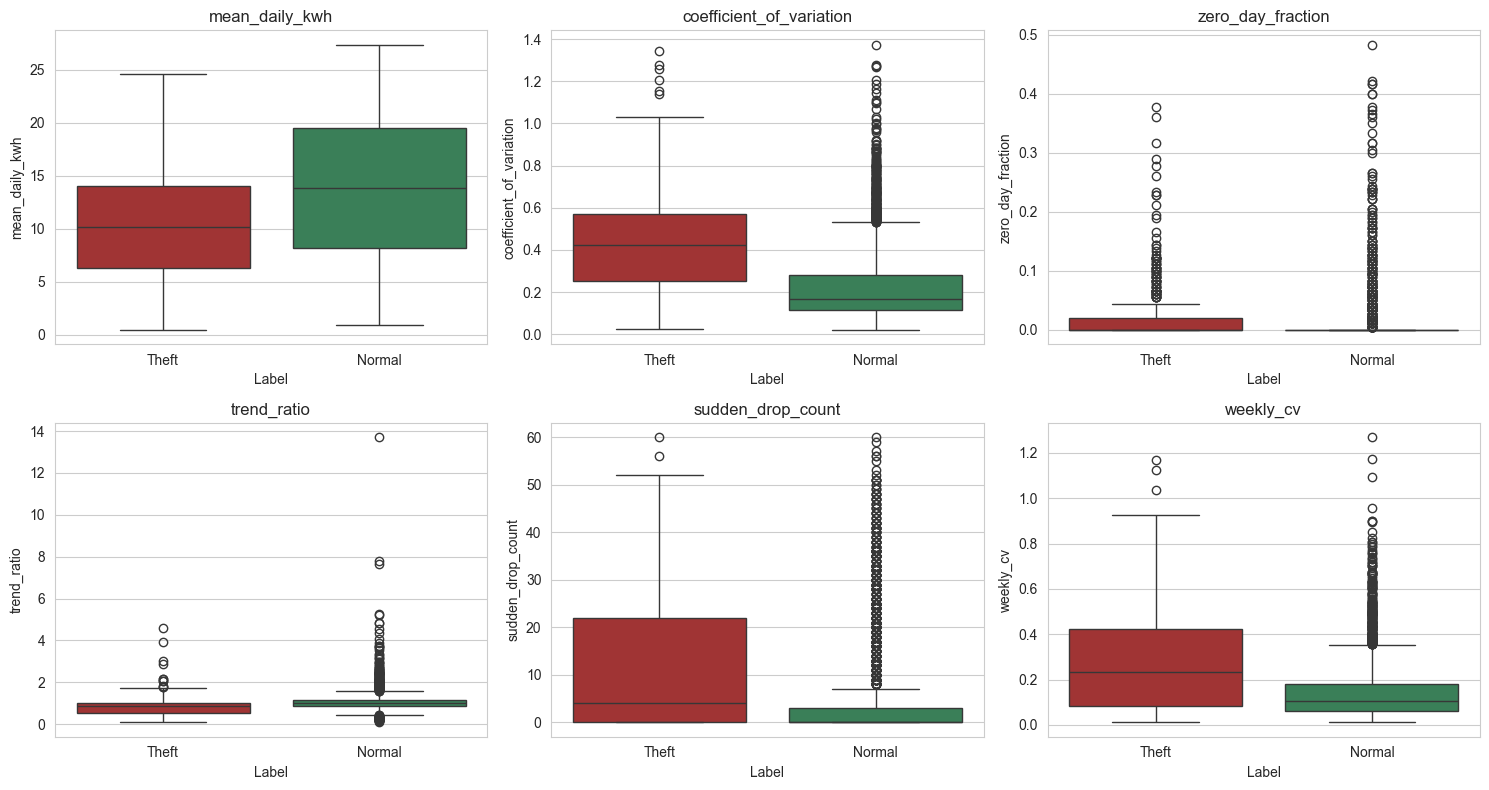

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_feats = ["mean_daily_kwh", "coefficient_of_variation", "zero_day_fraction",
              "trend_ratio", "sudden_drop_count", "weekly_cv"]
for ax, feat in zip(axes.flat, plot_feats):
    sns.boxplot(data=feat_df, x="Label", y=feat, hue="Label",
                palette={"Normal": "seagreen", "Theft": "firebrick"}, ax=ax, legend=False)
    ax.set_title(feat)
plt.tight_layout()
plt.savefig("../report_assets/feature_boxplots.png", dpi=150)
plt.show()

## 5. Prepare Data for Modelling

In [14]:
feature_cols = [
    "mean_daily_kwh", "std_daily_kwh", "coefficient_of_variation",
    "min_daily_kwh", "max_daily_kwh", "median_daily_kwh", "zero_day_fraction",
    "trend_ratio", "weekday_weekend_ratio", "sudden_drop_count",
    "weekly_cv", "near_cap_fraction", "max_to_mean_ratio",
]

X = feat_df[feature_cols]
y = LabelEncoder().fit_transform(feat_df["Label"])  # Normal=0, Theft=1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Theft ratio in train:", y_train.mean().round(3), " test:", y_test.mean().round(3))

Train shape: (2400, 13)  Test shape: (600, 13)
Theft ratio in train: 0.142  test: 0.142


## 6. Model Training & Comparison
Because theft cases are a minority class (~14%), we use `class_weight="balanced"`
/ equivalent so the model doesn't just predict "Normal" for everyone.

In [15]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
}

results = []
fitted_models = {}
for name, model in models.items():
    if name in ("Logistic Regression", "SVM (RBF)"):
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    results.append({"Model": name, "Accuracy": acc, "F1-Score (Theft)": f1, "ROC-AUC": auc})
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("F1-Score (Theft)", ascending=False)
results_df

,Model,Accuracy,F1-Score (Theft),ROC-AUC
2,Gradient Boosting,0.971667,0.894410,0.991296
1,Random Forest,0.970000,0.886076,0.989812
3,SVM (RBF),0.935000,0.800000,0.984146
0,Logistic Regression,0.913333,0.731959,0.966054


In [16]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
print("Best model selected:", best_name)

Best model selected: Gradient Boosting


## 7. Detailed Evaluation of Best Model

In [17]:
if best_name in ("Logistic Regression", "SVM (RBF)"):
    best_preds = best_model.predict(X_test_scaled)
    best_proba = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    best_preds = best_model.predict(X_test)
    best_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_preds, target_names=["Normal", "Theft"]))

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       515
       Theft       0.95      0.85      0.89        85

    accuracy                           0.97       600
   macro avg       0.96      0.92      0.94       600
weighted avg       0.97      0.97      0.97       600



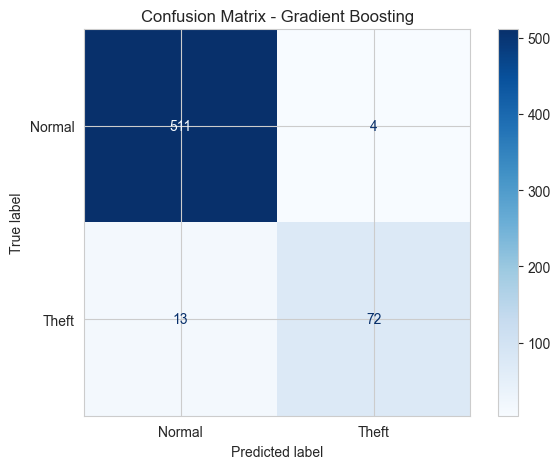

In [18]:
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Theft"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig("../report_assets/confusion_matrix.png", dpi=150)
plt.show()

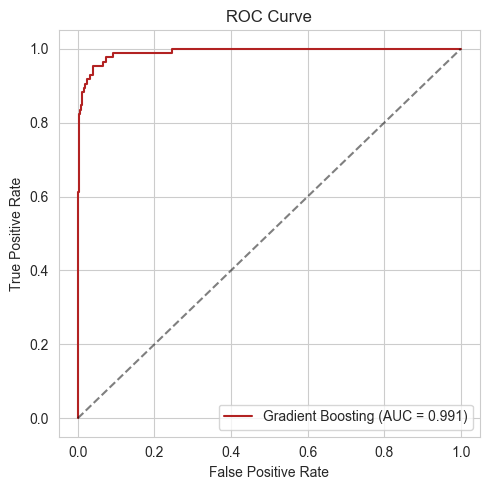

In [19]:
fpr, tpr, _ = roc_curve(y_test, best_proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"{best_name} (AUC = {roc_auc_score(y_test, best_proba):.3f})", color="firebrick")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../report_assets/roc_curve.png", dpi=150)
plt.show()

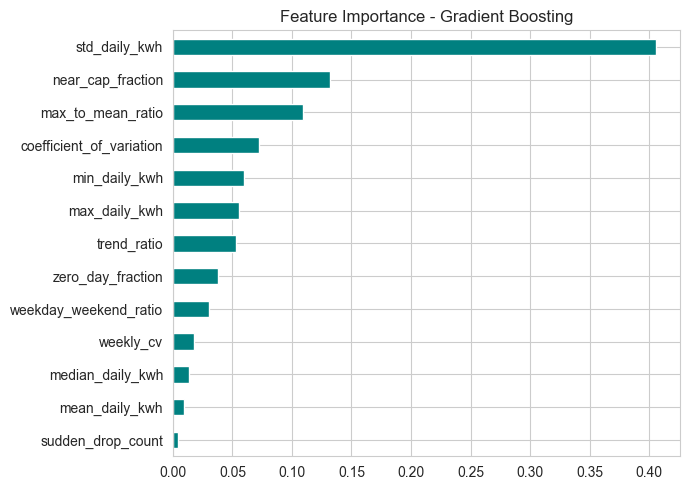

In [20]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
    plt.figure(figsize=(7, 5))
    importances.plot(kind="barh", color="teal")
    plt.title(f"Feature Importance - {best_name}")
    plt.tight_layout()
    plt.savefig("../report_assets/feature_importance.png", dpi=150)
    plt.show()

## 8. Save Final Model Artefacts

In [21]:
joblib.dump(best_model, "../model/theft_detection_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(feature_cols, "../model/feature_columns.json")
results_df.to_csv("../report_assets/model_comparison.csv", index=False)
print("Saved model, scaler and feature list to ../model/")
print(results_df)

Saved model, scaler and feature list to ../model/
                 Model  Accuracy  F1-Score (Theft)   ROC-AUC
2    Gradient Boosting  0.971667          0.894410  0.991296
1        Random Forest  0.970000          0.886076  0.989812
3            SVM (RBF)  0.935000          0.800000  0.984146
0  Logistic Regression  0.913333          0.731959  0.966054


## 9. Conclusion
The engineered behavioural features (zero-day fraction, trend ratio,
weekday/weekend ratio, sudden-drop count, weekly CV) successfully separate
theft/tampering consumers from normal consumers. The best-performing model
is deployed in a Streamlit app (`app/streamlit_app.py`) that lets a utility
analyst either enter a consumer's recent daily readings or upload a CSV of
multiple consumers, and get back a theft-risk prediction with probability,
to prioritise field inspection.